# Boosted Regression Tree (BRT) Periyar - Combined

In [2]:
! pip install mlxtend

In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import sklearn.metrics as metrics

# libraries for Multicollinearity
from sklearn.linear_model import LinearRegression

#libraries for feature selection
from sklearn.feature_selection import RFE
from mlxtend.feature_selection import SequentialFeatureSelector as sfs

# libraries for optimize hyperparameters
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression  # MaxEnt Model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score

In [6]:
# Load and balance dataset
csv_path = r"C:\Users\megha\OneDrive - University of Twente\Combined_Multi_ML.csv"

df = pd.read_csv(csv_path)
print("Columns in the dataset:", df.columns)

Columns in the dataset: Index(['wkt_geom', 'Aspect1', 'DistToRoad', 'DistToStre', 'Elevation1',
       'FlowDir1', 'LULC1', 'NDBI1', 'NDVI1', 'NDWI1', 'PlanarCurv',
       'Rainfall1', 'Rainfall2', 'Rainfall3', 'Rainfall4', 'Rainfall5',
       'Rainfall6', 'Rainfall7', 'Rainfall8', 'Rainfall9', 'Rainfall10',
       'Rainfall11', 'Slope1', 'SPI1', 'STI1', 'TPI1', 'TRI1', 'TWI1', 'WRI1',
       'Target_Var'],
      dtype='object')


In [8]:

num_rows, num_columns = df.shape
print(f"Total Rows: {num_rows}")
print(f"Total Columns: {num_columns}")

print("\nFirst 5 Rows:")
print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

Total Rows: 6432
Total Columns: 30

First 5 Rows:
                                            wkt_geom   Aspect1  DistToRoad  \
0  PointZ (660808.91387751756701618 1125912.32571...  0.452086   30.002138   
1  PointZ (655919.37658706970978528 1137256.37391...       NaN   42.430210   
2  PointZ (661792.93298613862134516 1138300.14105...       NaN  180.013779   
3  PointZ (646884.05534000787883997 1138047.13062...       NaN   67.090622   
4  PointZ (653209.34352380444761366 1139662.58189...       NaN   84.861305   

   DistToStre  Elevation1  FlowDir1  LULC1     NDBI1     NDVI1     NDWI1  ...  \
0  212.132034    0.083799  0.450980     10  0.445073  0.667561  0.271971  ...   
1  276.586334    0.064516  0.988858     10       NaN       NaN       NaN  ...   
2  150.000000    0.084375  0.587744     50       NaN       NaN       NaN  ...   
3   84.852814    0.266667  0.806723     10       NaN       NaN       NaN  ...   
4  228.473190    0.034562  0.376045     50       NaN       NaN       NaN  ..

Features (X) Shape: (6432, 28)
Target (y) Shape: (6432,)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Accuracy: 0.7114
Precision: 0.7616
Recall: 0.7114

Confusion Matrix:
 [[544 129 292]
 [ 24 370  47]
 [ 48  17 459]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.56      0.69       965
           1       0.72      0.84      0.77       441
           2       0.58      0.88      0.69       524

    accuracy                           0.71      1930
   macro avg       0.73      0.76      0.72      1930
weighted avg       0.76      0.71      0.71      1930



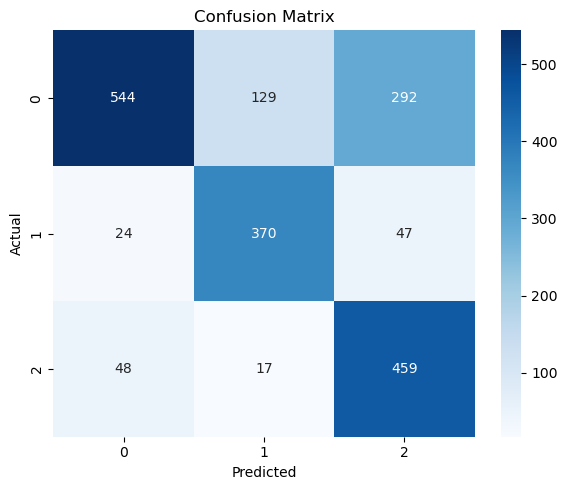

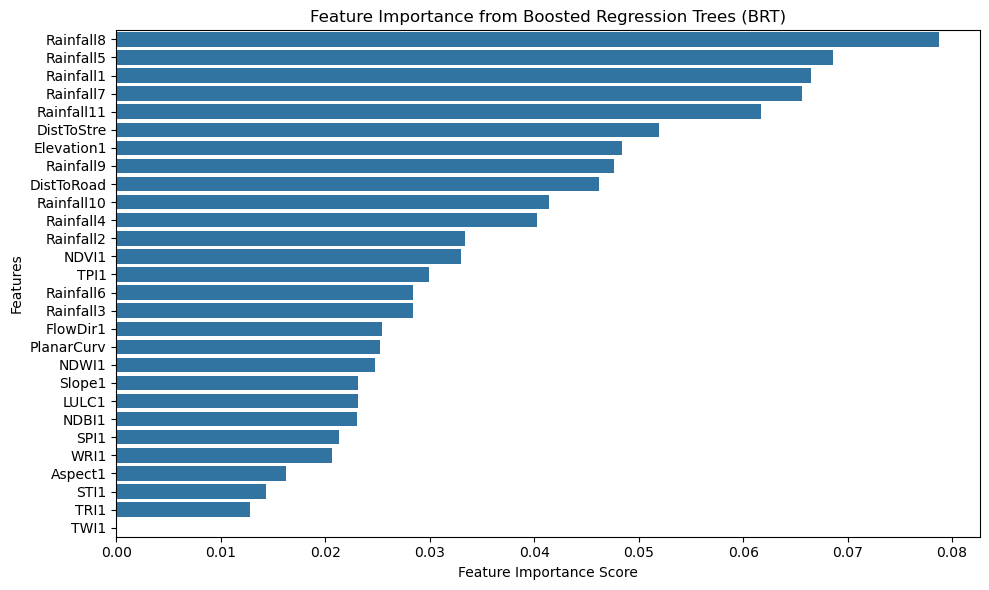

In [14]:
# ==== IMPORTS ====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import ClusterCentroids

# ==== DATA PREPARATION ====

# Define target column
target_column = "Target_Var"

# Shuffle and reset index
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Fill missing values with zero
df = df.fillna(0)

# Define features and labels
X = df.drop(columns=[target_column, "wkt_geom"])
y = df[target_column]

# Display shapes
print(f"Features (X) Shape: {X.shape}")
print(f"Target (y) Shape: {y.shape}")

# ==== TRAIN-TEST SPLIT ====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# ==== APPLY CLUSTER CENTROIDS UNDERSAMPLING ====
cc = ClusterCentroids(random_state=42)
X_train_res, y_train_res = cc.fit_resample(X_train, y_train)

# ==== APPLY BORDERLINE SMOTE OVERSAMPLING ====
smote = BorderlineSMOTE(random_state=42, kind='borderline-1')  # 'borderline-1' for minority class focus
X_train_res, y_train_res = smote.fit_resample(X_train_res, y_train_res)

# ==== HYPERPARAMETER GRID ====
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

brt = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=brt,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# ==== RUN GRID SEARCH ====
grid_search.fit(X_train_res, y_train_res)

# Retrieve best model
best_model = grid_search.best_estimator_
print("\nBest Parameters:", grid_search.best_params_)

# ==== MAKE PREDICTIONS ====
y_pred = best_model.predict(X_test)

# ==== METRICS ====
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", report)

# ==== PLOT CONFUSION MATRIX ====
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# ==== FEATURE IMPORTANCE PLOT ====
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance from Boosted Regression Trees (BRT)')
plt.tight_layout()
plt.show()


Features (X) Shape: (6432, 28)
Target (y) Shape: (6432,)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Accuracy: 0.7176
Precision: 0.7614
Recall: 0.7176

Confusion Matrix:
 [[542 142 281]
 [ 23 384  34]
 [ 56   9 459]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.56      0.68       965
           1       0.72      0.87      0.79       441
           2       0.59      0.88      0.71       524

    accuracy                           0.72      1930
   macro avg       0.73      0.77      0.73      1930
weighted avg       0.76      0.72      0.71      1930



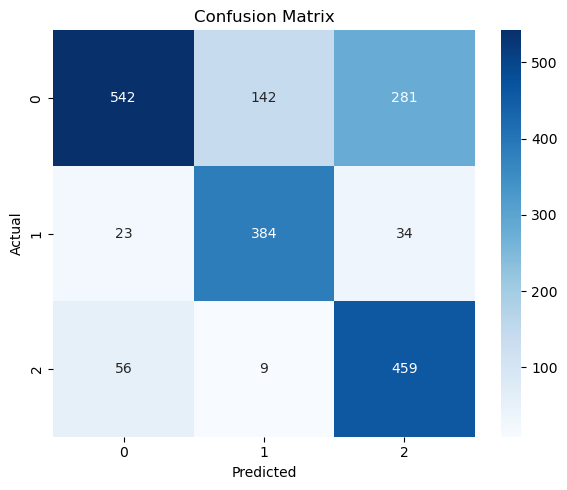

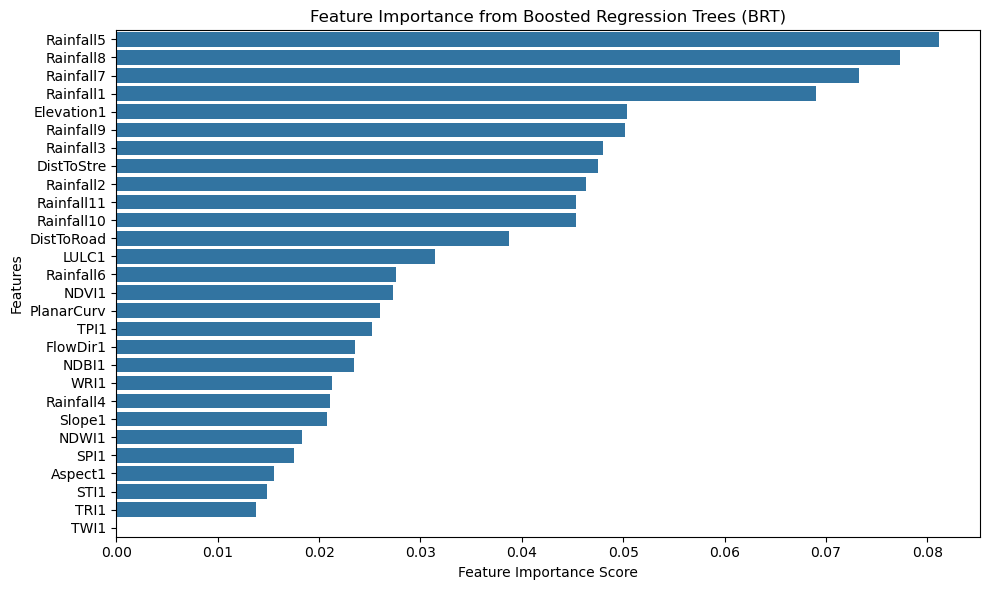

In [18]:
# ==== IMPORTS ====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import ClusterCentroids

# ==== DATA PREPARATION ====

# Define target column
target_column = "Target_Var"

# Shuffle and reset index
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Fill missing values with zero
df = df.fillna(0)

# Define features and labels
X = df.drop(columns=[target_column, "wkt_geom"])
y = df[target_column]

# Display shapes
print(f"Features (X) Shape: {X.shape}")
print(f"Target (y) Shape: {y.shape}")

# ==== TRAIN-TEST SPLIT ====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# ==== APPLY CLUSTER CENTROIDS UNDERSAMPLING ====
cc = ClusterCentroids(random_state=42)
X_train_res, y_train_res = cc.fit_resample(X_train, y_train)

# ==== APPLY BORDERLINE SMOTE OVERSAMPLING ====
smote = BorderlineSMOTE(random_state=42, kind='borderline-1')  # 'borderline-1' for minority class focus
X_train_res, y_train_res = smote.fit_resample(X_train_res, y_train_res)

# ==== HYPERPARAMETER GRID ====
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

brt = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=brt,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# ==== RUN GRID SEARCH ====
grid_search.fit(X_train_res, y_train_res)

# Retrieve best model
best_model = grid_search.best_estimator_
print("\nBest Parameters:", grid_search.best_params_)

# ==== MAKE PREDICTIONS ====
y_pred = best_model.predict(X_test)

# ==== METRICS ====
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", report)

# ==== PLOT CONFUSION MATRIX ====
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# ==== FEATURE IMPORTANCE PLOT ====
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance from Boosted Regression Trees (BRT)')
plt.tight_layout()
plt.show()


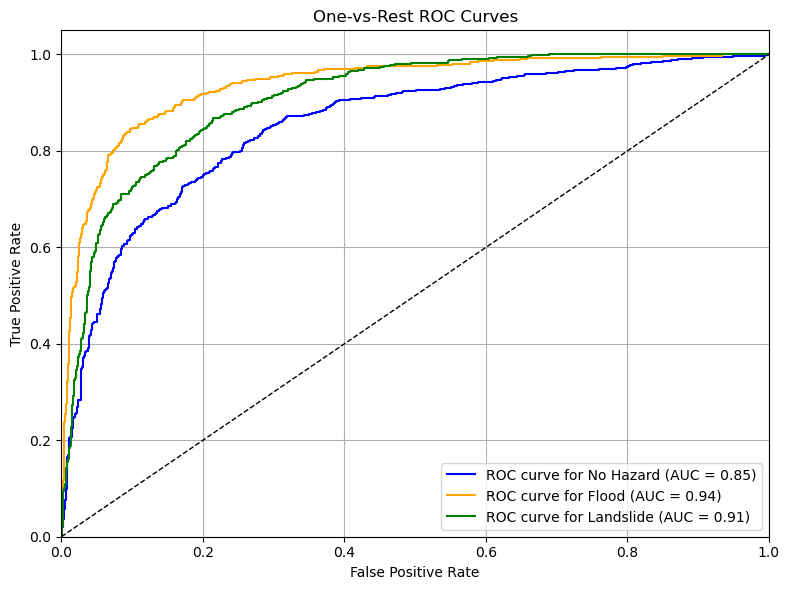

In [16]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Binarize the output (one-hot encoding)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = best_model.predict_proba(X_test)
n_classes = y_test_bin.shape[1]

# Plot ROC curves for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'orange', 'green']
labels = ['No Hazard', 'Flood', 'Landslide']

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i],
             label=f"ROC curve for {labels[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curves")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
import pandas as pd

# ==== Predict labels and probabilities ====
y_pred = best_model.predict(X_test)                # replace `brt` with your actual BRT model variable
y_proba = best_model.predict_proba(X_test)

# ==== Build DataFrame ====
df_brt = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': y_pred,
    'Prob_Class_0': y_proba[:, 0],
    'Prob_Class_1': y_proba[:, 1],
    'Prob_Class_2': y_proba[:, 2]
})

# ==== Save CSV ====
save_path = r"C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\BRT_Combined_Results.csv"
df_brt.to_csv(save_path, index=False)

print(f"✅ BRT multi-class predictions saved to: {save_path}")


✅ BRT multi-class predictions saved to: C:\Users\megha\OneDrive - University of Twente\Thesis Data\ML Data\Results\BRT_Combined_Results.csv


In [10]:
! pip install shap imbalanced-learn pandas scikit-learn matplotlib seaborn

In [11]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.ensemble import BalancedRandomForestClassifier


# SHAP Explanation using Permutation Explainer (Recommended for ensemble models)
explainer = shap.Explainer(brt.predict, X_train, algorithm="permutation")
shap_values = explainer(X_test)

# SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test)

# SHAP Bar Plot (Feature Importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar")

# SHAP Dependence Plot (for the most important feature)
most_important_feature = X.columns[np.argmax(np.abs(shap_values.values).mean(axis=0))]
shap.dependence_plot(most_important_feature, shap_values.values, X_test)

# Show plots
plt.show()

NotFittedError: This GradientBoostingClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.